# Abdelrahman's Environmental Questions

This notebook answers **three new environmental questions** using the final integrated dataset.

The analysis uses all six air-quality pollutants:

- PM2.5
- PM10
- O3
- NO2
- CO
- SO2

Because these pollutants have very different units and scales, the notebook creates a **Normalized Pollution Index (NPI)** by min-max scaling every pollutant from 0 to 1 and averaging them. This makes the combined air-quality score fairer than simply adding the raw pollutant values together.

> Higher NPI = worse overall air quality.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'CO', 'SO2']
weather_cols = ['Temperature_mean', 'Temperature_max', 'Humidity', 'Wind_speed', 'Pressure']

# The notebook is designed to sit inside Data Analysis/src/notebooks.
# It also includes fallbacks so it can run from the original notebooks folder or from this exported location.
possible_paths = [
    Path('../../Data/final/environment_data.csv'),
    Path('../Data/final/environment_data.csv'),
    Path('Data/final/environment_data.csv'),
    Path('/mnt/data/da_project/Data Analysis/Data/final/environment_data.csv')
]

for path in possible_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError('Could not find environment_data.csv. Please update data_path manually.')

df = pd.read_csv(data_path, parse_dates=['Date'])

# Add time features
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

# Normalize pollutants globally, then average them into one combined index
norm_pollutants = df[pollutants].copy()
for col in pollutants:
    norm_pollutants[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())
    df[col + '_norm'] = norm_pollutants[col]

df['Pollution_Index'] = norm_pollutants.mean(axis=1)

print('Dataset shape:', df.shape)
print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())
print('Cities:', ', '.join(sorted(df['City'].unique())))
print('Missing values:', int(df.isna().sum().sum()))
df.head()

Dataset shape: (2548, 26)
Date range: 2023-01-01 to 2023-12-31
Cities: Cairo, Dubai, London, Nairobi, New York, Paris, Tokyo
Missing values: 0


,City,Date,PM2.5,PM10,O3,NO2,CO,SO2,Green_Space,Temperature_mean,Temperature_max,Humidity,Wind_speed,Pressure,Electricity Consumption,isWeekend,Season,Month,Month_Name,PM2.5_norm,PM10_norm,O3_norm,NO2_norm,CO_norm,SO2_norm,Pollution_Index
0,Cairo,2023-01-01,36.337500,60.341667,33.333333,36.100000,337.416667,34.795833,53,15.888889,20.0,75.333333,8.511111,1007.247111,1.116235e+10,0,Winter,1,Jan,0.376442,0.163039,0.145794,0.191870,0.088742,0.220280,0.197694
1,Cairo,2023-01-02,49.379167,78.937500,18.625000,46.704167,442.000000,55.141667,53,16.044444,21.0,70.844444,7.888889,1006.393556,1.116235e+10,0,Winter,1,Jan,0.523211,0.217010,0.078607,0.251260,0.129755,0.349826,0.258278
2,Cairo,2023-01-03,34.066667,51.825000,24.583333,44.612500,387.041667,48.670833,53,15.288889,19.0,75.911111,6.644444,1006.458667,1.116235e+10,0,Winter,1,Jan,0.350886,0.138321,0.105824,0.239545,0.108203,0.308625,0.208567
3,Cairo,2023-01-04,30.737500,43.029167,38.958333,37.420833,322.166667,42.025000,53,15.777778,19.0,78.377778,7.022222,1007.377111,1.116235e+10,0,Winter,1,Jan,0.313420,0.112792,0.171488,0.199267,0.082761,0.266309,0.191006
4,Cairo,2023-01-05,23.145833,34.125000,29.041667,48.162500,415.166667,50.412500,53,16.136364,19.0,61.795455,5.704545,1008.101818,1.116235e+10,0,Winter,1,Jan,0.227985,0.086949,0.126190,0.259428,0.119232,0.319715,0.189916


## Question 1 — Which season has the worst overall air quality?

This question checks whether pollution changes by season across the cities. It uses all six pollutants through the Normalized Pollution Index and also checks pollutant-specific seasonal patterns.


In [2]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_summary = df.groupby('Season')['Pollution_Index'].agg(['mean', 'median', 'std', 'count']).reindex(season_order)
season_summary

,mean,median,std,count
Season,,,,
Winter,0.144862,0.122405,0.073681,628
Spring,0.153682,0.137420,0.073464,639
Summer,0.157504,0.135524,0.096204,644
Autumn,0.137624,0.108990,0.079173,637


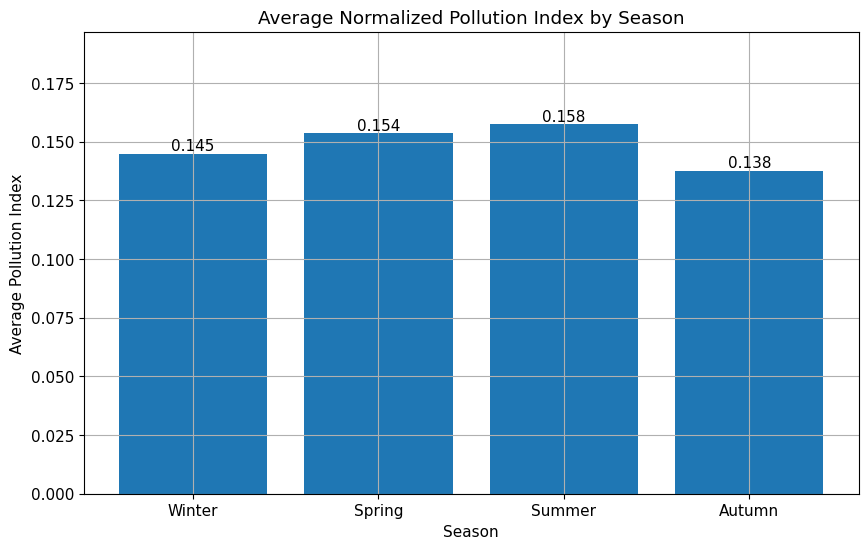

In [3]:
# Visualization 1: Average pollution index by season
season_means = season_summary['mean']

plt.figure()
plt.bar(season_means.index, season_means.values)
plt.title('Average Normalized Pollution Index by Season')
plt.xlabel('Season')
plt.ylabel('Average Pollution Index')
plt.ylim(0, season_means.max() * 1.25)
for i, value in enumerate(season_means.values):
    plt.text(i, value, f'{value:.3f}', ha='center', va='bottom')
plt.show()

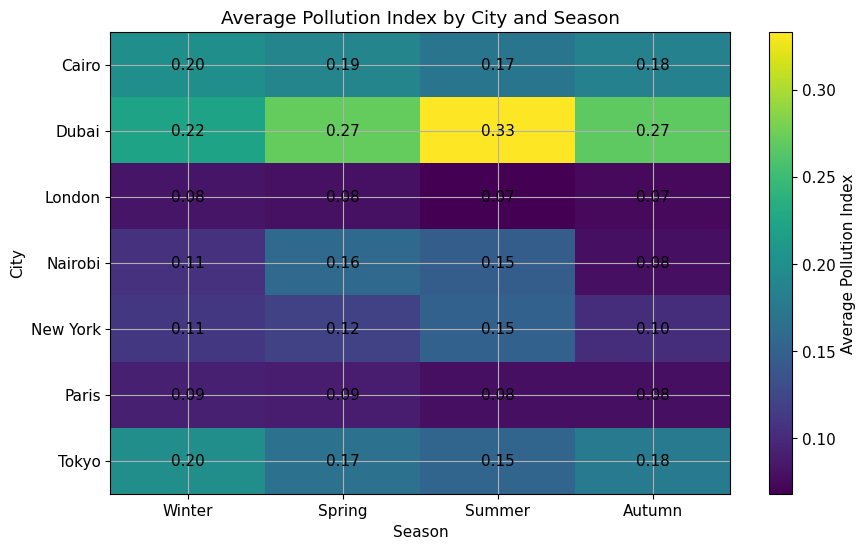

In [4]:
# Visualization 2: City-season heatmap
city_season = df.pivot_table(index='City', columns='Season', values='Pollution_Index', aggfunc='mean')
city_season = city_season[season_order]

plt.figure(figsize=(10, 6))
plt.imshow(city_season.values, aspect='auto')
plt.title('Average Pollution Index by City and Season')
plt.xlabel('Season')
plt.ylabel('City')
plt.xticks(range(len(city_season.columns)), city_season.columns)
plt.yticks(range(len(city_season.index)), city_season.index)
plt.colorbar(label='Average Pollution Index')
for i in range(city_season.shape[0]):
    for j in range(city_season.shape[1]):
        plt.text(j, i, f'{city_season.iloc[i, j]:.2f}', ha='center', va='center')
plt.show()

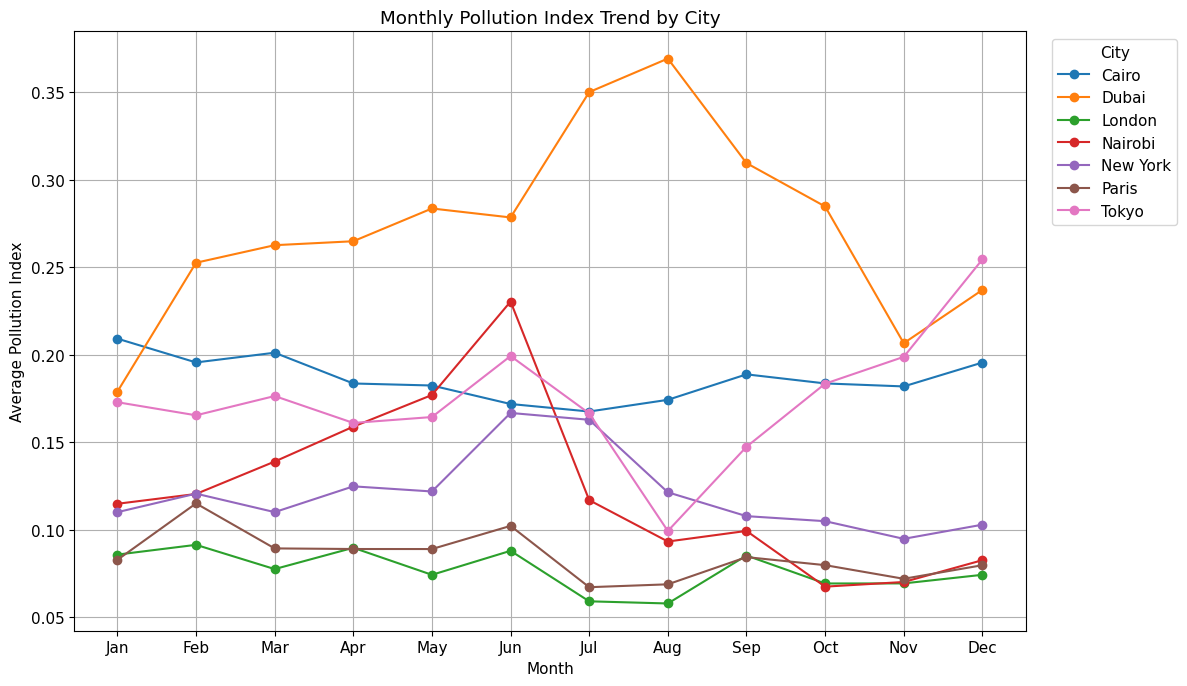

In [5]:
# Visualization 3: Monthly pollution trend by city
monthly_city = df.groupby(['Month', 'City'])['Pollution_Index'].mean().reset_index()

plt.figure(figsize=(12, 7))
for city in sorted(df['City'].unique()):
    city_data = monthly_city[monthly_city['City'] == city]
    plt.plot(city_data['Month'], city_data['Pollution_Index'], marker='o', label=city)
plt.title('Monthly Pollution Index Trend by City')
plt.xlabel('Month')
plt.ylabel('Average Pollution Index')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

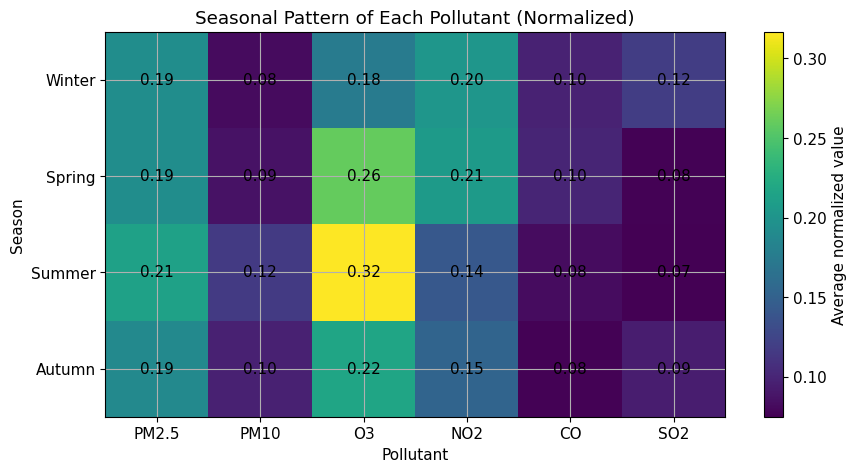

In [6]:
# Visualization 4: Pollutant-specific seasonal pattern using normalized pollutants
season_pollutants = df.groupby('Season')[[p + '_norm' for p in pollutants]].mean().reindex(season_order)
season_pollutants.columns = pollutants

plt.figure(figsize=(10, 5))
plt.imshow(season_pollutants.values, aspect='auto')
plt.title('Seasonal Pattern of Each Pollutant (Normalized)')
plt.xlabel('Pollutant')
plt.ylabel('Season')
plt.xticks(range(len(pollutants)), pollutants)
plt.yticks(range(len(season_pollutants.index)), season_pollutants.index)
plt.colorbar(label='Average normalized value')
for i in range(season_pollutants.shape[0]):
    for j in range(season_pollutants.shape[1]):
        plt.text(j, i, f'{season_pollutants.iloc[i, j]:.2f}', ha='center', va='center')
plt.show()

### Insights for Question 1

- **Summer has the highest overall pollution index** in the dataset, followed closely by Spring.
- **Autumn has the lowest overall pollution index**.
- The pattern is not identical in every city. Dubai has the strongest summer pollution peak, while Cairo and Tokyo show stronger winter pollution compared with some other seasons.
- Looking at the pollutant-specific heatmap, **O3 is more seasonal and rises in warmer periods**, while **NO2, CO, and SO2 are relatively more important in colder periods**.

**Answer:** Air quality does change by season. In this dataset, the worst overall air quality appears in **Summer**, but city-specific patterns matter a lot.


## Question 2 — Which weather conditions are associated with cleaner or worse air quality?

This question checks the relationship between weather and air pollution. It compares temperature, humidity, wind speed, and pressure against all six pollutants plus the combined Pollution Index.


In [7]:
corr_data = df[weather_cols + pollutants + ['Pollution_Index']].corr()
weather_pollution_corr = corr_data.loc[weather_cols, pollutants + ['Pollution_Index']]
weather_pollution_corr.round(3)

,PM2.5,PM10,O3,NO2,CO,SO2,Pollution_Index
Temperature_mean,0.533,0.596,0.593,0.127,0.174,0.213,0.560
Temperature_max,0.507,0.559,0.599,0.100,0.186,0.191,0.535
Humidity,-0.393,-0.410,-0.328,-0.211,-0.096,-0.255,-0.429
Wind_speed,-0.142,-0.047,0.075,-0.121,-0.229,-0.076,-0.129
Pressure,0.116,0.122,-0.152,0.389,-0.402,0.208,0.110


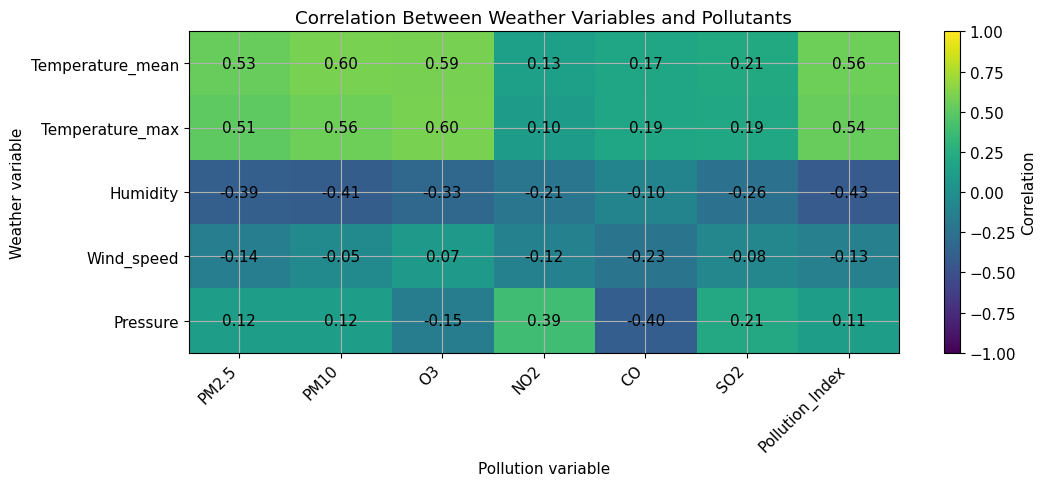

In [8]:
# Visualization 5: Weather vs pollution correlation heatmap
corr_matrix = weather_pollution_corr

plt.figure(figsize=(11, 5))
plt.imshow(corr_matrix.values, aspect='auto', vmin=-1, vmax=1)
plt.title('Correlation Between Weather Variables and Pollutants')
plt.xlabel('Pollution variable')
plt.ylabel('Weather variable')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.colorbar(label='Correlation')
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center')
plt.tight_layout()
plt.show()

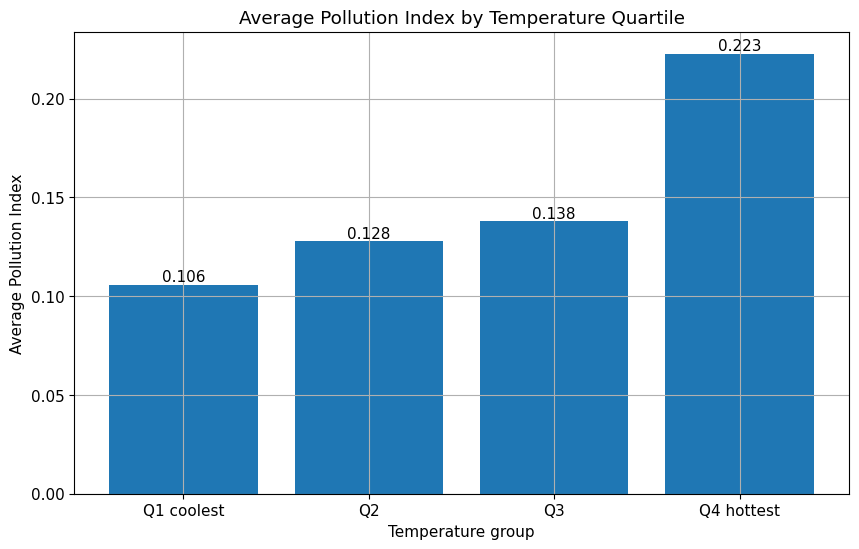

In [9]:
# Visualization 6: Temperature quartiles vs pollution index
# Q1 means coolest days, Q4 means hottest days.
df['Temperature_Quartile'] = pd.qcut(df['Temperature_mean'], 4, labels=['Q1 coolest', 'Q2', 'Q3', 'Q4 hottest'])
temp_q = df.groupby('Temperature_Quartile', observed=False)['Pollution_Index'].mean()

plt.figure()
plt.bar(temp_q.index.astype(str), temp_q.values)
plt.title('Average Pollution Index by Temperature Quartile')
plt.xlabel('Temperature group')
plt.ylabel('Average Pollution Index')
for i, value in enumerate(temp_q.values):
    plt.text(i, value, f'{value:.3f}', ha='center', va='bottom')
plt.show()

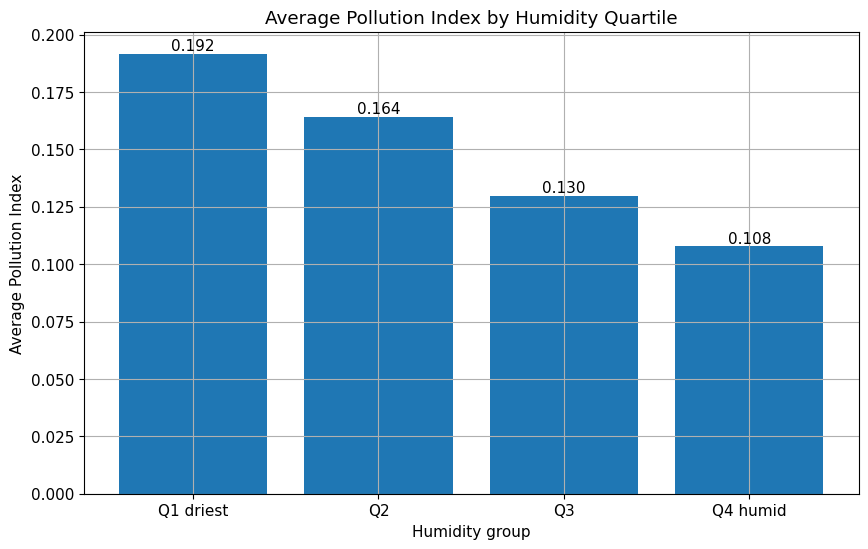

In [10]:
# Visualization 7: Humidity quartiles vs pollution index
# Q1 means driest days, Q4 means most humid days.
df['Humidity_Quartile'] = pd.qcut(df['Humidity'], 4, labels=['Q1 driest', 'Q2', 'Q3', 'Q4 humid'])
humidity_q = df.groupby('Humidity_Quartile', observed=False)['Pollution_Index'].mean()

plt.figure()
plt.bar(humidity_q.index.astype(str), humidity_q.values)
plt.title('Average Pollution Index by Humidity Quartile')
plt.xlabel('Humidity group')
plt.ylabel('Average Pollution Index')
for i, value in enumerate(humidity_q.values):
    plt.text(i, value, f'{value:.3f}', ha='center', va='bottom')
plt.show()

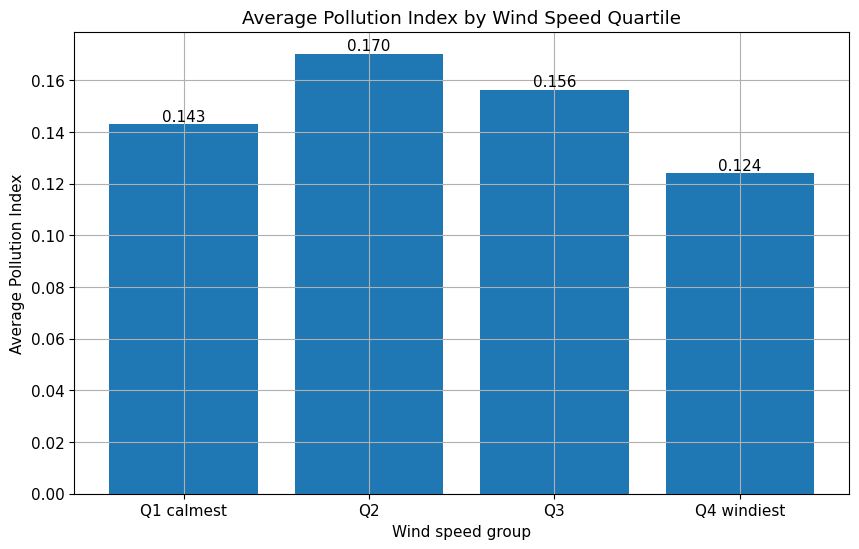

In [11]:
# Visualization 8: Wind speed quartiles vs pollution index
# Q1 means calmest days, Q4 means windiest days.
df['Wind_Quartile'] = pd.qcut(df['Wind_speed'], 4, labels=['Q1 calmest', 'Q2', 'Q3', 'Q4 windiest'])
wind_q = df.groupby('Wind_Quartile', observed=False)['Pollution_Index'].mean()

plt.figure()
plt.bar(wind_q.index.astype(str), wind_q.values)
plt.title('Average Pollution Index by Wind Speed Quartile')
plt.xlabel('Wind speed group')
plt.ylabel('Average Pollution Index')
for i, value in enumerate(wind_q.values):
    plt.text(i, value, f'{value:.3f}', ha='center', va='bottom')
plt.show()

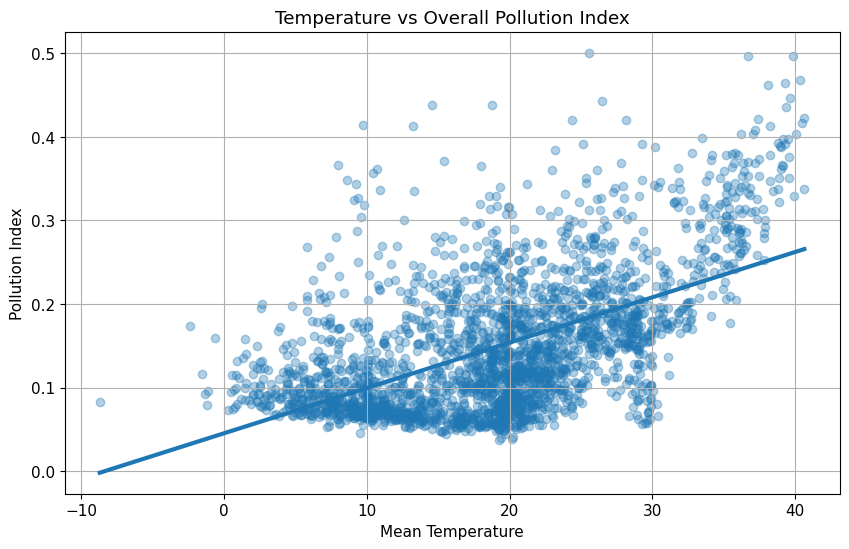

In [12]:
# Visualization 9: Temperature vs Pollution Index scatter with trend line
x = df['Temperature_mean']
y = df['Pollution_Index']
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.35)
plt.plot(np.sort(x), trend(np.sort(x)), linewidth=3)
plt.title('Temperature vs Overall Pollution Index')
plt.xlabel('Mean Temperature')
plt.ylabel('Pollution Index')
plt.show()

### Insights for Question 2

- Temperature has a **positive relationship** with the overall Pollution Index. The hottest quartile has a much higher average pollution index than the coolest quartile.
- Humidity has a **negative relationship** with the Pollution Index. More humid days are associated with lower overall pollution in this dataset.
- Wind speed has a weaker relationship overall, but the windiest group has the lowest pollution index, which makes environmental sense because wind can help disperse pollution.
- O3, PM2.5, and PM10 are especially connected with temperature in this dataset.

**Answer:** The worst air-quality conditions are generally associated with **hotter and drier days**, while higher humidity and stronger wind are linked with cleaner air.


## Question 3 — Which cities have the highest risk of high-pollution days, and which pollutants drive those days?

This question identifies extreme pollution days using the combined index. A day is marked as a **bad air day** if its Pollution Index is in the top 10% of all city-days in the dataset.


In [13]:
bad_day_threshold = df['Pollution_Index'].quantile(0.90)
df['Bad_Air_Day'] = df['Pollution_Index'] >= bad_day_threshold

bad_days_by_city = df.groupby('City')['Bad_Air_Day'].agg(['sum', 'mean', 'count'])
bad_days_by_city['Bad_Day_Rate_%'] = bad_days_by_city['mean'] * 100
bad_days_by_city = bad_days_by_city.sort_values('sum', ascending=False)

print('Bad air day threshold:', round(bad_day_threshold, 3))
bad_days_by_city[['sum', 'Bad_Day_Rate_%', 'count']]

Bad air day threshold: 0.267


,sum,Bad_Day_Rate_%,count
City,,,
Dubai,189,51.780822,365
Tokyo,37,10.136986,365
Nairobi,14,3.856749,363
Cairo,12,3.287671,365
New York,3,0.833333,360
London,0,0.000000,365
Paris,0,0.000000,365


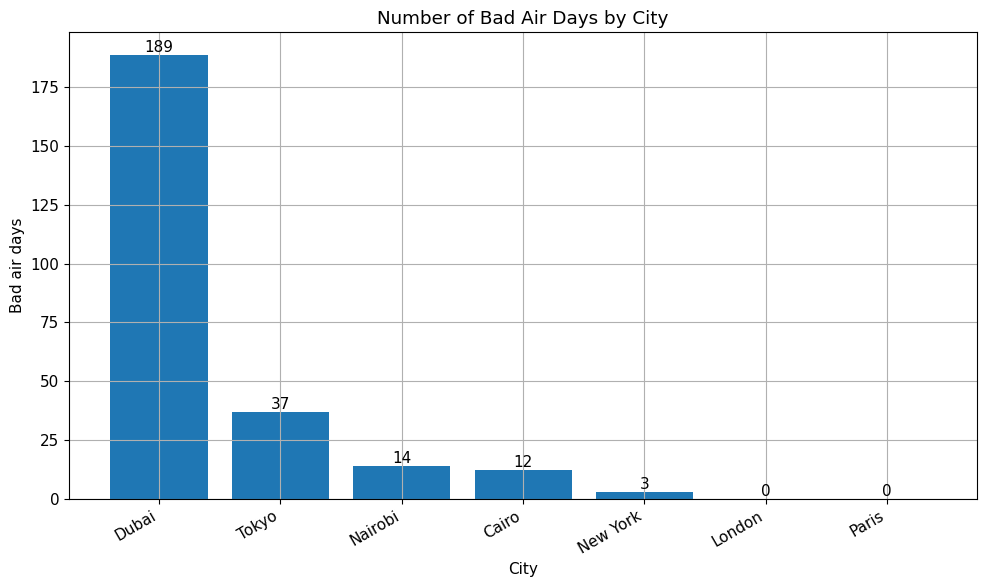

In [14]:
# Visualization 10: Number of bad air days by city
bad_day_counts = bad_days_by_city['sum']

plt.figure(figsize=(10, 6))
plt.bar(bad_day_counts.index, bad_day_counts.values)
plt.title('Number of Bad Air Days by City')
plt.xlabel('City')
plt.ylabel('Bad air days')
plt.xticks(rotation=30, ha='right')
for i, value in enumerate(bad_day_counts.values):
    plt.text(i, value, str(int(value)), ha='center', va='bottom')
plt.tight_layout()
plt.show()

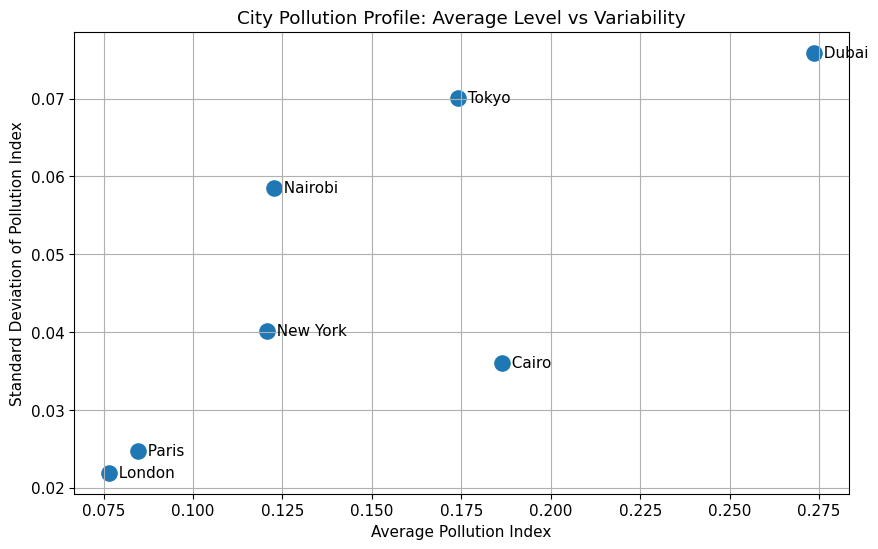

In [15]:
# Visualization 11: City average pollution vs pollution variability
city_profile = df.groupby('City')['Pollution_Index'].agg(['mean', 'std']).sort_values('mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.scatter(city_profile['mean'], city_profile['std'], s=120)
for city, row in city_profile.iterrows():
    plt.text(row['mean'], row['std'], '  ' + city, va='center')
plt.title('City Pollution Profile: Average Level vs Variability')
plt.xlabel('Average Pollution Index')
plt.ylabel('Standard Deviation of Pollution Index')
plt.show()

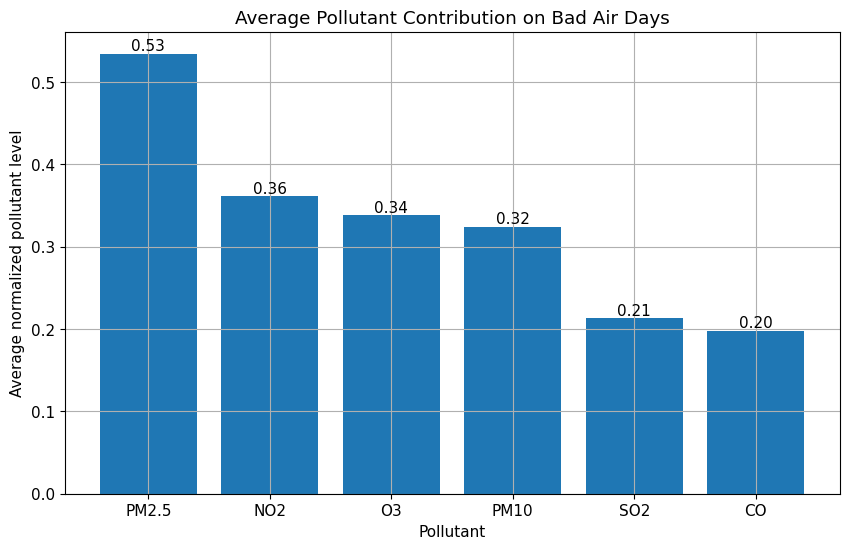

In [16]:
# Visualization 12: Which pollutants contribute most on global bad air days?
bad_day_contrib = df.loc[df['Bad_Air_Day'], [p + '_norm' for p in pollutants]].mean()
bad_day_contrib.index = pollutants
bad_day_contrib = bad_day_contrib.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(bad_day_contrib.index, bad_day_contrib.values)
plt.title('Average Pollutant Contribution on Bad Air Days')
plt.xlabel('Pollutant')
plt.ylabel('Average normalized pollutant level')
for i, value in enumerate(bad_day_contrib.values):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')
plt.show()

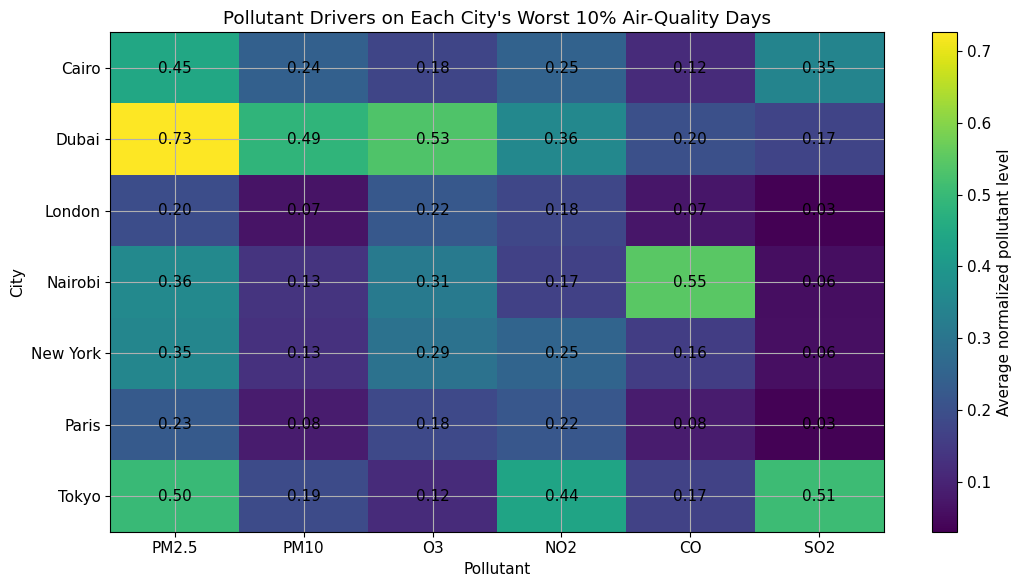

In [17]:
# Visualization 13: City-specific pollutant drivers on each city's worst 10% days
city_driver_rows = []
for city, city_df in df.groupby('City'):
    city_threshold = city_df['Pollution_Index'].quantile(0.90)
    city_worst = city_df[city_df['Pollution_Index'] >= city_threshold]
    row = city_worst[[p + '_norm' for p in pollutants]].mean()
    row.index = pollutants
    row.name = city
    city_driver_rows.append(row)

city_drivers = pd.DataFrame(city_driver_rows).sort_index()

plt.figure(figsize=(11, 6))
plt.imshow(city_drivers.values, aspect='auto')
plt.title("Pollutant Drivers on Each City's Worst 10% Air-Quality Days")
plt.xlabel('Pollutant')
plt.ylabel('City')
plt.xticks(range(len(city_drivers.columns)), city_drivers.columns)
plt.yticks(range(len(city_drivers.index)), city_drivers.index)
plt.colorbar(label='Average normalized pollutant level')
for i in range(city_drivers.shape[0]):
    for j in range(city_drivers.shape[1]):
        plt.text(j, i, f'{city_drivers.iloc[i, j]:.2f}', ha='center', va='center')
plt.tight_layout()
plt.show()

In [18]:
# Optional table: top 15 worst air-quality days in the whole dataset
worst_days = df.sort_values('Pollution_Index', ascending=False)[['Date', 'City', 'Season', 'Pollution_Index'] + pollutants].head(15)
worst_days

,Date,City,Season,Pollution_Index,PM2.5,PM10,O3,NO2,CO,SO2
419,2023-02-24,Dubai,Winter,0.500833,81.337500,143.375000,35.625000,180.391667,977.166667,35.100000
563,2023-07-18,Dubai,Summer,0.497229,73.254167,208.708333,220.333333,35.270833,680.541667,29.616667
587,2023-08-11,Dubai,Summer,0.497147,89.770833,244.608333,169.416667,32.325000,689.375000,22.558333
586,2023-08-10,Dubai,Summer,0.468769,82.225000,231.691667,145.833333,38.904167,674.125000,27.112500
591,2023-08-15,Dubai,Summer,0.464963,89.383333,197.770833,95.750000,63.583333,721.208333,37.658333
585,2023-08-09,Dubai,Summer,0.462234,67.037500,233.512500,165.291667,38.729167,662.750000,33.862500
553,2023-07-08,Dubai,Summer,0.447082,73.566667,203.558333,177.916667,35.308333,518.583333,24.529167
431,2023-03-08,Dubai,Spring,0.442919,69.804167,114.445833,58.458333,159.670833,749.666667,29.954167
2360,2023-06-25,Nairobi,Summer,0.438829,59.583333,87.912500,88.500000,52.541667,2661.125000,11.212500
1798,2023-12-10,Tokyo,Winter,0.438073,67.508333,96.850000,5.333333,64.170833,787.458333,157.254167


### Insights for Question 3

- The top 10% threshold for bad air days is around **0.267** on the normalized pollution index.
- **Dubai has by far the highest number of bad air days** in the dataset. More than half of Dubai's days pass the global top-10% pollution threshold.
- Tokyo has the second-highest number of bad air days, but much lower than Dubai.
- London and Paris do not appear in the global top-10% bad-air-day group.
- On global bad air days, the strongest average contributors are **PM2.5**, followed by **NO2**, **O3**, and **PM10**.
- City-specific drivers differ: Dubai's worst days are mainly driven by PM2.5, O3, and PM10; Tokyo's worst days are strongly affected by SO2, PM2.5, and NO2; Nairobi has a noticeable CO contribution on its worst days.

**Answer:** The city with the highest high-pollution-day risk is **Dubai**, and the most important bad-day pollutant overall is **PM2.5**, but the pollutant profile changes by city.


# Final Summary

The three strongest questions Abdelrahman can use are:

1. **Which season has the worst overall air quality?**  
   Answer: Summer is the worst overall season in this dataset, but some cities such as Cairo and Tokyo show important winter pollution patterns.

2. **Which weather conditions are associated with cleaner or worse air quality?**  
   Answer: Hotter and drier days are linked with worse overall air quality, while more humid and windier days are linked with cleaner air.

3. **Which cities have the highest risk of high-pollution days, and which pollutants drive those days?**  
   Answer: Dubai has the highest bad-air-day risk, and PM2.5 is the strongest overall driver of bad air days, although pollutant drivers differ by city.

This notebook is visualization-heavy and uses all six air-quality pollutants throughout the analysis.
